In [ ]:
from google.colab import files
uploaded = files.upload()

Saving features_3_sec.csv to features_3_sec.csv
Saving features_30_sec.csv to features_30_sec.csv


Loading datasets...

--- TASK 1A: Dataset Visualization ---
30-sec dataset shape: (1000, 61) (Samples: 1000, Dimensions: 58)
3-sec dataset shape: (9990, 61) (Samples: 9990, Dimensions: 58)


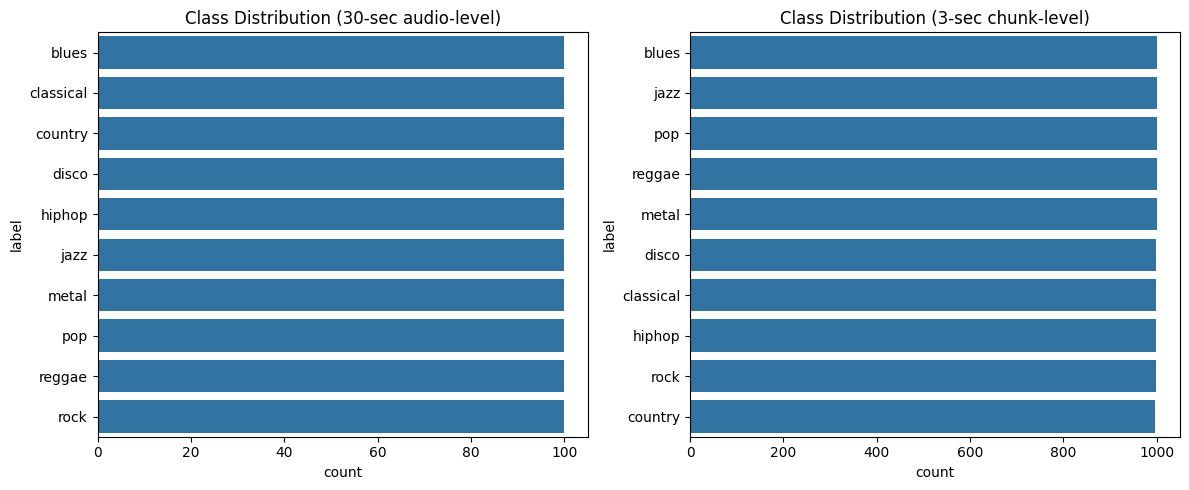


--- TASK 1B & 1C: Training on 30-second features ---

Results for Random Forest on 30-sec Data:
Classification Accuracy: 0.6600
Macro F1-score: 0.6565


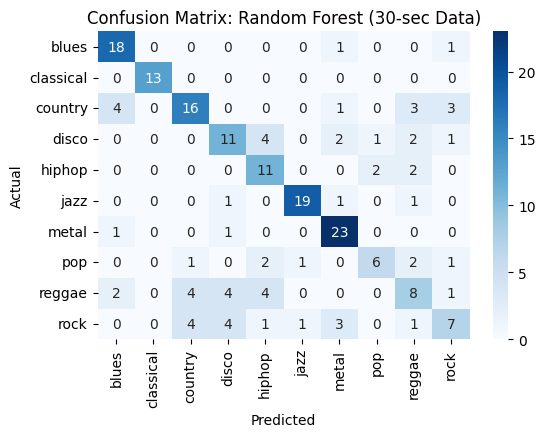


Results for SVM on 30-sec Data:
Classification Accuracy: 0.7000
Macro F1-score: 0.7006


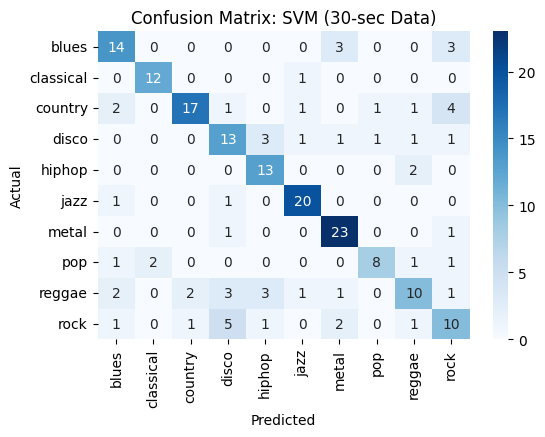


--- TASK 1B & 1C: Training on 3-second features (with Majority Voting) ---

Results for Random Forest on 3-sec Data (Voted):
Classification Accuracy: 0.7450
Macro F1-score: 0.7442


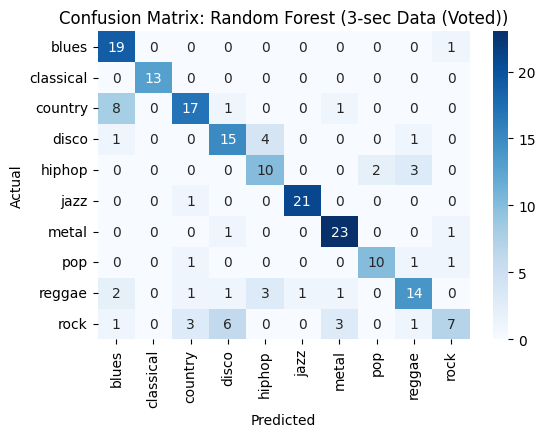


Results for SVM on 3-sec Data (Voted):
Classification Accuracy: 0.7700
Macro F1-score: 0.7587


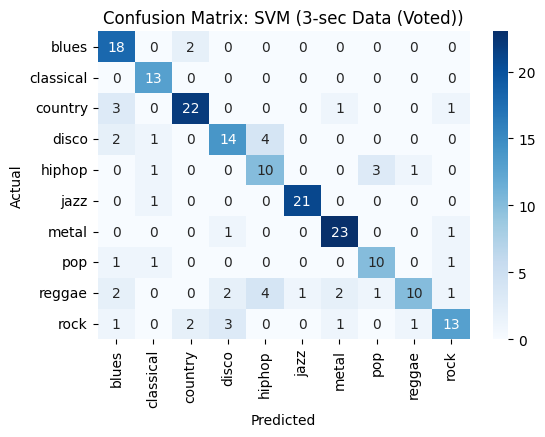


Task 1 Code Execution Complete. Review the output metrics and charts to write your Task 1D comparison.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Phase 0: Data Loading & Preparation
# ==========================================
print("Loading datasets...")
# Load the datasets [cite: 13, 14, 15]
df_30 = pd.read_csv('features_30_sec.csv')
df_3 = pd.read_csv('features_3_sec.csv')

# The GTZAN filenames usually look like "blues.00000.wav" (30s) and "blues.00000.0.wav" (3s).
# We need to extract the base song ID (e.g., "blues.00000") to ensure a strict song-level split.
def extract_song_id(filename):
    parts = filename.split('.')
    return f"{parts[0]}.{parts[1]}"

df_30['song_id'] = df_30['filename'].apply(extract_song_id)
df_3['song_id'] = df_3['filename'].apply(extract_song_id)

# ==========================================
# TASK 1A: Dataset Visualization [cite: 18]
# ==========================================
print("\n--- TASK 1A: Dataset Visualization ---")
print(f"30-sec dataset shape: {df_30.shape} (Samples: {df_30.shape[0]}, Dimensions: {df_30.shape[1]-3})")
print(f"3-sec dataset shape: {df_3.shape} (Samples: {df_3.shape[0]}, Dimensions: {df_3.shape[1]-3})")

# Visualizing Class Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(y='label', data=df_30, order=df_30['label'].value_counts().index)
plt.title('Class Distribution (30-sec audio-level)')

plt.subplot(1, 2, 2)
sns.countplot(y='label', data=df_3, order=df_3['label'].value_counts().index)
plt.title('Class Distribution (3-sec chunk-level)')
plt.tight_layout()
plt.show()

# ==========================================
# Phase 0.5: Song-Level Train-Test Split
# ==========================================
# Get unique songs
unique_songs = df_30['song_id'].unique()

# Split the unique song IDs into train and test sets (80/20 split)
train_songs, test_songs = train_test_split(unique_songs, test_size=0.2, random_state=42)

# Apply this split to both datasets
train_30 = df_30[df_30['song_id'].isin(train_songs)]
test_30 = df_30[df_30['song_id'].isin(test_songs)]

train_3 = df_3[df_3['song_id'].isin(train_songs)]
test_3 = df_3[df_3['song_id'].isin(test_songs)]

# Separate features (X) and labels (y)
drop_cols = ['filename', 'length', 'label', 'song_id']
X_train_30 = train_30.drop(columns=drop_cols)
y_train_30 = train_30['label']
X_test_30 = test_30.drop(columns=drop_cols)
y_test_30 = test_30['label']

X_train_3 = train_3.drop(columns=drop_cols)
y_train_3 = train_3['label']
X_test_3 = test_3.drop(columns=drop_cols)
y_test_3 = test_3['label']

# Encode labels
le = LabelEncoder()
y_train_30_enc = le.fit_transform(y_train_30)
y_test_30_enc = le.transform(y_test_30)
y_train_3_enc = le.transform(y_train_3)
y_test_3_enc = le.transform(y_test_3)

# Scale features (Crucial for SVM and general performance)
scaler = StandardScaler()
X_train_30_scaled = scaler.fit_transform(X_train_30)
X_test_30_scaled = scaler.transform(X_test_30)

X_train_3_scaled = scaler.fit_transform(X_train_3) # Refit scaler for 3s dataset features
X_test_3_scaled = scaler.transform(X_test_3)

# ==========================================
# Helper Function for Evaluation [cite: 22]
# ==========================================
def evaluate_model(y_true, y_pred, model_name, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nResults for {model_name} on {dataset_name}:")
    print(f"Classification Accuracy: {acc:.4f}")
    print(f"Macro F1-score: {f1:.4f}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix: {model_name} ({dataset_name})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# ==========================================
# TASK 1B (i) & 1C: 30-second Feature Models [cite: 20]
# ==========================================
print("\n--- TASK 1B & 1C: Training on 30-second features ---")

# Model 1: Random Forest [cite: 19]
rf_30 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_30.fit(X_train_30_scaled, y_train_30_enc)
rf_preds_30 = rf_30.predict(X_test_30_scaled)
evaluate_model(y_test_30_enc, rf_preds_30, "Random Forest", "30-sec Data")

# Model 2: Support Vector Machine (SVM) [cite: 19]
svm_30 = SVC(kernel='rbf', probability=True, random_state=42)
svm_30.fit(X_train_30_scaled, y_train_30_enc)
svm_preds_30 = svm_30.predict(X_test_30_scaled)
evaluate_model(y_test_30_enc, svm_preds_30, "SVM", "30-sec Data")

# ==========================================
# TASK 1B (ii) & 1C: 3-second Feature Models with Voting [cite: 21]
# ==========================================
print("\n--- TASK 1B & 1C: Training on 3-second features (with Majority Voting) ---")

# Train Models on 3-second chunks [cite: 21]
rf_3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_3.fit(X_train_3_scaled, y_train_3_enc)

svm_3 = SVC(kernel='rbf', probability=True, random_state=42)
svm_3.fit(X_train_3_scaled, y_train_3_enc)

# Predict on 3-second test chunks
test_3_with_preds = test_3.copy()
test_3_with_preds['rf_pred'] = rf_3.predict(X_test_3_scaled)
test_3_with_preds['svm_pred'] = svm_3.predict(X_test_3_scaled)
test_3_with_preds['true_label'] = y_test_3_enc

# Aggregate segment predictions to obtain a final song-level label using majority voting [cite: 21]
def majority_vote(group, pred_col):
    # Returns the most frequent prediction in the group
    return group[pred_col].mode()[0]

# Group by the original song_id to aggregate the 10 chunks back into 1 prediction per song
aggregated_results = test_3_with_preds.groupby('song_id').apply(
    lambda x: pd.Series({
        'true_label': x['true_label'].iloc[0], # True label is the same for all chunks of a song
        'rf_final_pred': majority_vote(x, 'rf_pred'),
        'svm_final_pred': majority_vote(x, 'svm_pred')
    })
).reset_index()

# Evaluate aggregated results [cite: 22]
evaluate_model(aggregated_results['true_label'], aggregated_results['rf_final_pred'], "Random Forest", "3-sec Data (Voted)")
evaluate_model(aggregated_results['true_label'], aggregated_results['svm_final_pred'], "SVM", "3-sec Data (Voted)")

print("\nTask 1 Code Execution Complete. Review the output metrics and charts to write your Task 1D comparison.")

Task 2


--- TASK 2: Dimensionality Reduction using PCA ---
Original number of features: 57
Number of features after PCA (retaining 95% variance): 39


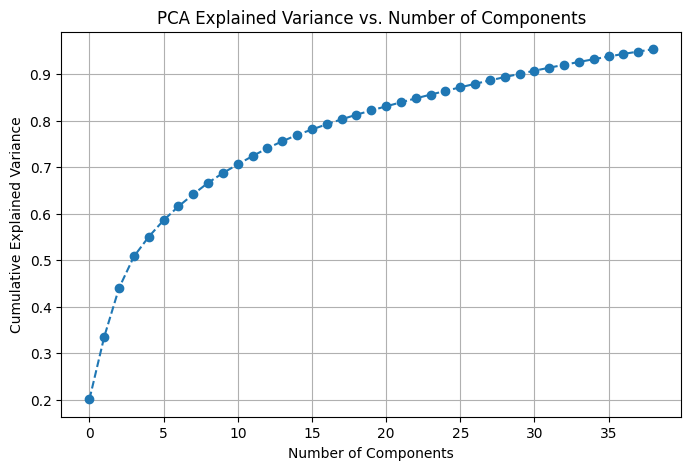


Training SVM on PCA-reduced features...

--- Evaluation Metrics (SVM with PCA) ---
Classification Accuracy: 0.7700
Macro F1-score: 0.7635


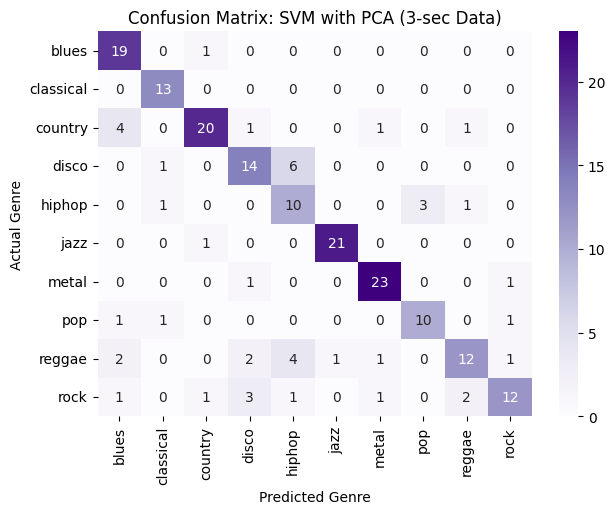

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("--- TASK 2: Dimensionality Reduction using PCA ---")

# ==========================================
# 1. Data Loading & Song-Level Split
# ==========================================
# We will use the 3-second dataset as it generally provides better performance
df_3 = pd.read_csv('features_3_sec.csv')

# Extract base song ID to prevent data leakage (e.g., "blues.00000.0.wav" -> "blues.00000")
df_3['song_id'] = df_3['filename'].apply(lambda x: f"{x.split('.')[0]}.{x.split('.')[1]}")

# Create an 80/20 train-test split based on unique song IDs
unique_songs = df_3['song_id'].unique()
train_songs, test_songs = train_test_split(unique_songs, test_size=0.2, random_state=42)

train_3 = df_3[df_3['song_id'].isin(train_songs)]
test_3 = df_3[df_3['song_id'].isin(test_songs)]

# Separate features and labels
drop_cols = ['filename', 'length', 'label', 'song_id']
X_train = train_3.drop(columns=drop_cols)
y_train = train_3['label']
X_test = test_3.drop(columns=drop_cols)
y_test = test_3['label']

# Encode the text labels into numbers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Scale features (PCA is highly sensitive to the scale of the data!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. Apply Principal Component Analysis (PCA)
# ==========================================
print(f"Original number of features: {X_train_scaled.shape[1]}")

# We tell PCA to keep 95% of the variance in the data.
# It will automatically figure out how many components (features) are needed to hit 95%.
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Number of features after PCA (retaining 95% variance): {X_train_pca.shape[1]}")

# Visualize the cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# ==========================================
# 3. Retrain the Best Model (SVM) & Evaluate
# ==========================================
print("\nTraining SVM on PCA-reduced features...")
# Using the same hyperparameters from Task 1 for a fair comparison
svm_pca = SVC(kernel='rbf', probability=True, random_state=42)
svm_pca.fit(X_train_pca, y_train_enc)

# Predict on the test set
test_3_with_preds = test_3.copy()
test_3_with_preds['svm_pca_pred'] = svm_pca.predict(X_test_pca)
test_3_with_preds['true_label'] = y_test_enc

# Aggregate predictions back to the song level using Majority Voting
def majority_vote(group):
    return group['svm_pca_pred'].mode()[0]

aggregated_results = test_3_with_preds.groupby('song_id').apply(
    lambda x: pd.Series({
        'true_label': x['true_label'].iloc[0],
        'final_pred': majority_vote(x)
    })
).reset_index()

# Calculate Evaluation Metrics
y_true_final = aggregated_results['true_label']
y_pred_final = aggregated_results['final_pred']

acc = accuracy_score(y_true_final, y_pred_final)
f1 = f1_score(y_true_final, y_pred_final, average='macro')
cm = confusion_matrix(y_true_final, y_pred_final)

print("\n--- Evaluation Metrics (SVM with PCA) ---")
print(f"Classification Accuracy: {acc:.4f}")
print(f"Macro F1-score: {f1:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: SVM with PCA (3-sec Data)')
plt.ylabel('Actual Genre')
plt.xlabel('Predicted Genre')
plt.show()

Task 3

--- TASK 3: Spectrogram-based Deep Learning (Optimized CNN) ---
Features: Batch Norm, Dynamic LR, GAP, & Gaussian Noise
Loading image data from directory...
Found 999 files belonging to 10 classes.
Using 800 files for training.
Found 999 files belonging to 10 classes.
Using 199 files for validation.
Detected Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Building the Clean, Deep CNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 288, 432, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 286, 430, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 143, 215, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 141, 213, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 70, 106, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 68, 104, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 34, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 11, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,261,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,651,402 (6.30 MB)

 Trainable params: 1,651,402 (6.30 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 408ms/step - accuracy: 0.1025 - loss: 2.4585 - val_accuracy: 0.0854 - val_loss: 2.3913
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.1587 - loss: 2.3542 - val_accuracy: 0.2111 - val_loss: 2.2617
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.2100 - loss: 2.2044 - val_accuracy: 0.2814 - val_loss: 2.0617
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.2650 - loss: 2.0709 - val_accuracy: 0.2312 - val_loss: 2.0168
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.3225 - loss: 1.9831 - val_accuracy: 0.4271 - val_loss: 1.8510
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.3175 - loss: 1.8335 - val_accuracy: 0.3266 - val_loss: 1.7715
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.4038 - loss: 1.6972 - val_accuracy: 0.4724 - val_loss: 1.5128
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.4512 - loss: 1.

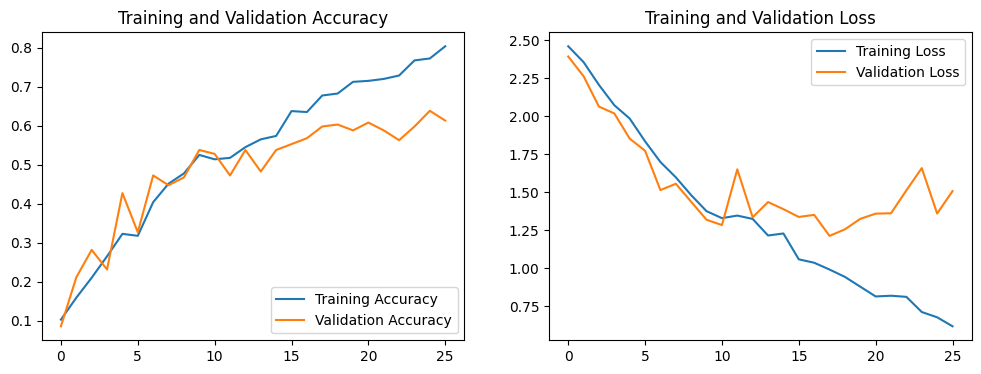


Generating Evaluation Metrics on Validation Set...

Classification Report:
              precision    recall  f1-score   support

       blues       0.75      0.38      0.50        24
   classical       0.94      0.88      0.91        17
     country       0.44      0.55      0.49        20
       disco       0.43      0.50      0.46        18
      hiphop       0.57      0.73      0.64        22
        jazz       0.55      0.57      0.56        21
       metal       0.92      0.73      0.81        15
         pop       0.75      0.75      0.75        28
      reggae       0.46      0.46      0.46        24
        rock       0.36      0.40      0.38        10

    accuracy                           0.60       199
   macro avg       0.62      0.59      0.60       199
weighted avg       0.62      0.60      0.60       199



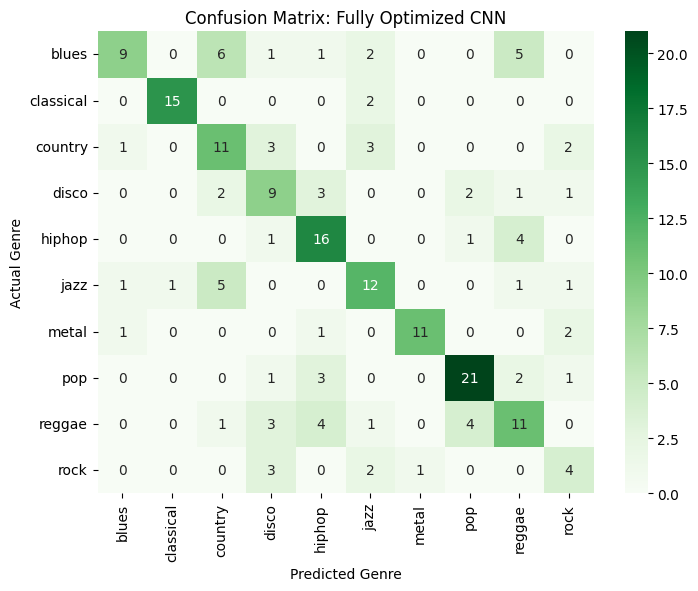

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("--- TASK 3: Spectrogram-based Deep Learning (Optimized CNN) ---")
print("Features: Batch Norm, Dynamic LR, GAP, & Gaussian Noise")

# ==========================================
# 1. Hyperparameters & Data Loading
# ==========================================
BATCH_SIZE = 32
IMG_HEIGHT = 288
IMG_WIDTH = 432
EPOCHS = 20 # Increased safely due to Early Stopping
INITIAL_LEARNING_RATE = 0.001

# Google Drive path for Colab
data_dir = '/content/drive/MyDrive/dataset /images_original'

print("Loading image data from directory...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Detected Genres: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 2. Design the Clean, Deep CNN Architecture
# ==========================================
print("\nBuilding the Clean, Deep CNN Model...")

num_classes = len(class_names)

model = models.Sequential([
    # Input & Rescaling
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 4 (Deep pooling to shrink the image naturally)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 5
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # The image is now small enough to safely flatten without creating 29 million parameters
    layers.Flatten(),

    # Single Dense Layer with L2 Regularization and Dropout
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

# Standard Adam optimizer with a safe, default learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 3. Train the Model
# ==========================================
print("\nStarting Training...")

# Clean Early Stopping
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', # Back to monitoring loss for accurate stopping
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stopping]
)

# ==========================================
# 4. Evaluation and Visualization
# ==========================================
actual_epochs = len(history.history['loss'])
epochs_range = range(actual_epochs)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Generate Confusion Matrix
print("\nGenerating Evaluation Metrics on Validation Set...")
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Fully Optimized CNN')
plt.ylabel('Actual Genre')
plt.xlabel('Predicted Genre')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
